# 双均线策略 — 量化分析与回测

**TASK3 Phase 3** | 2026-07-05

---

## 目录
1. 理论基础：金叉/死叉 + 量化指标
2. 数据加载
3. 均线计算
4. 交易信号生成
5. 可视化
6. 模拟交易与回测
7. 多股票多周期对比实验
8. 总结与心得

## 1. 理论基础

### 1.1 双均线策略

双均线策略是最经典的趋势跟踪策略之一。其核心思想是：

- **短期均线 (MA_short)**：反映近期价格趋势，对价格变化敏感
- **长期均线 (MA_long)**：反映中长期价格趋势，变化平缓

通过两条均线的交叉关系判断趋势转折：

| 信号 | 名称 | 条件 | 操作 |
|------|------|------|------|
| 🟢 **金叉** | Golden Cross | MA_short 上穿 MA_long | 买入 |
| 🔴 **死叉** | Death Cross | MA_short 下穿 MA_long | 卖出 |

### 1.2 量化评价指标

- **累计回报 (Cumulative Return)**：策略总收益率 $CR = (V_{end} - V_0) / V_0$
- **年化收益率 (Annualized Return)**：折算年化 $AR = (1+CR)^{252/N} - 1$
- **最大回撤 (MDD)**：净值最高点到后续最低点的最大跌幅
- **夏普比率 (Sharpe Ratio)**：$Sharpe = R_{daily} / \sigma_{daily} \times \sqrt{252}$
- **胜率 (Win Rate)**：盈利交易次数 / 总交易次数

## 2. 环境准备与数据加载

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from pathlib import Path

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (14, 8)

# 自动定位数据目录（适配不同运行路径）
NB_DIR = Path().resolve()
if (NB_DIR / 'data' / 'standard').exists():
    DATA_DIR = NB_DIR / 'data' / 'standard'
elif (NB_DIR / 'TASK3' / 'data' / 'standard').exists():
    DATA_DIR = NB_DIR / 'TASK3' / 'data' / 'standard'
else:
    DATA_DIR = Path('TASK3/data/standard')
print('数据目录:', DATA_DIR.resolve())
print('可用股票:', sorted(os.listdir(DATA_DIR)))

数据目录: /Users/wangyanpeng15/git_repo/AI/AI-Quant/TASK3/data/standard
可用股票: ['002594.SZ', '00981.HK', '01211.HK', '600900.SH', '688099.SH', '688981.SH']


In [10]:
def load_stock_data(symbol: str) -> pd.DataFrame:
    path = DATA_DIR / symbol / '1d.parquet'
    df = pd.read_parquet(path)
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df = df.sort_values('trade_date').reset_index(drop=True)
    df.set_index('trade_date', inplace=True)
    print(f'{symbol}: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')
    print(f'  前复权收盘价: {df["close"].iloc[0]:.2f} ~ {df["close"].iloc[-1]:.2f}')
    return df

df = load_stock_data('002594.SZ')
df.head()

002594.SZ: 1818 行, 2019-01-02 ~ 2026-07-03
  前复权收盘价: 15.91 ~ 88.47


,symbol,open,high,low,close,volume,amount,pct_chg
trade_date,,,,,,,,
2019-01-02,002594.SZ,16.50,16.62,15.84,15.91,85554.45,424670.600,0.0000
2019-01-03,002594.SZ,15.93,16.13,15.52,15.55,83477.60,407386.244,-2.2627
2019-01-04,002594.SZ,15.46,16.50,15.37,16.38,126537.87,627892.541,5.3376
2019-01-07,002594.SZ,16.45,16.78,16.17,16.62,136045.50,693197.812,1.4652
2019-01-08,002594.SZ,16.92,17.35,16.84,17.11,147051.57,777381.422,2.9483


## 3. 均线计算

设置短期和长期均线周期，计算移动平均线。默认参数：**短均线 5 日，长均线 15 日**。

In [11]:
def calc_ma(df: pd.DataFrame, short_window: int = 5, long_window: int = 15) -> pd.DataFrame:
    df = df.copy()
    df['ma_short'] = df['close'].rolling(window=short_window, min_periods=1).mean()
    df['ma_long'] = df['close'].rolling(window=long_window, min_periods=1).mean()
    print(f'MA{short_window}: {df["ma_short"].iloc[-1]:.2f}')
    print(f'MA{long_window}: {df["ma_long"].iloc[-1]:.2f}')
    return df

SHORT_WINDOW = 5
LONG_WINDOW = 15

df = calc_ma(df, SHORT_WINDOW, LONG_WINDOW)
df[['close', 'ma_short', 'ma_long']].tail(10)

MA5: 82.41
MA15: 85.07


,close,ma_short,ma_long
trade_date,,,
2026-06-22,87.59,88.730,91.341333
2026-06-23,85.00,87.566,90.764667
2026-06-24,83.30,86.298,89.867333
2026-06-25,82.20,85.244,89.026000
2026-06-26,78.20,83.258,88.010000
2026-06-29,79.64,81.668,87.118667
2026-06-30,79.70,80.608,86.352667
2026-07-01,80.66,80.080,85.604000
2026-07-02,83.57,80.354,85.154667


## 4. 交易信号生成

逻辑：
- **金叉买入**：MA_short 上穿 MA_long（前一日 short < long，当日 short > long）
- **死叉卖出**：MA_short 下穿 MA_long（前一日 short > long，当日 short < long）
- 不允许做空，卖出后空仓等待下一次金叉

In [12]:
def generate_signals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['signal'] = 0
    prev_short_above = df['ma_short'].shift(1) > df['ma_long'].shift(1)
    curr_short_above = df['ma_short'] > df['ma_long']
    golden_cross = (~prev_short_above) & curr_short_above
    df.loc[golden_cross, 'signal'] = 1
    death_cross = prev_short_above & (~curr_short_above)
    df.loc[death_cross, 'signal'] = -1

    df['position'] = 0
    in_position = False
    for i in range(len(df)):
        if df['signal'].iloc[i] == 1 and not in_position:
            in_position = True
        elif df['signal'].iloc[i] == -1 and in_position:
            in_position = False
        df.iloc[i, df.columns.get_loc('position')] = 1 if in_position else 0

    print(f'买入信号: {(df["signal"]==1).sum()} 次, 卖出信号: {(df["signal"]==-1).sum()} 次')
    print(f'最新持仓状态: {"持仓" if df["position"].iloc[-1]==1 else "空仓"}')
    return df

df = generate_signals(df)
print('\n最近的交易信号:')
signal_df = df[df['signal'] != 0][['close', 'ma_short', 'ma_long', 'signal']].tail(10)
signal_df

买入信号: 69 次, 卖出信号: 69 次
最新持仓状态: 空仓

最近的交易信号:


,close,ma_short,ma_long,signal
trade_date,,,,
2025-12-04,95.24,95.570,95.299333,1
2025-12-17,95.21,95.644,95.691333,-1
2025-12-26,100.01,95.690,95.564000,1
2026-01-13,97.19,97.230,97.358667,-1
2026-02-13,90.27,90.916,90.603333,1
2026-04-03,99.01,102.922,103.896000,-1
2026-04-16,105.54,103.662,102.639333,1
2026-04-24,99.46,101.100,101.655333,-1
2026-06-03,94.82,95.458,95.412000,1


## 5. 可视化

绘制股价 + 双均线 + 买卖信号标记。
- 🔴 **红色▲** = 金叉买入点
- 🟢 **绿色▼** = 死叉卖出点

saved: dual_ma_002594.png


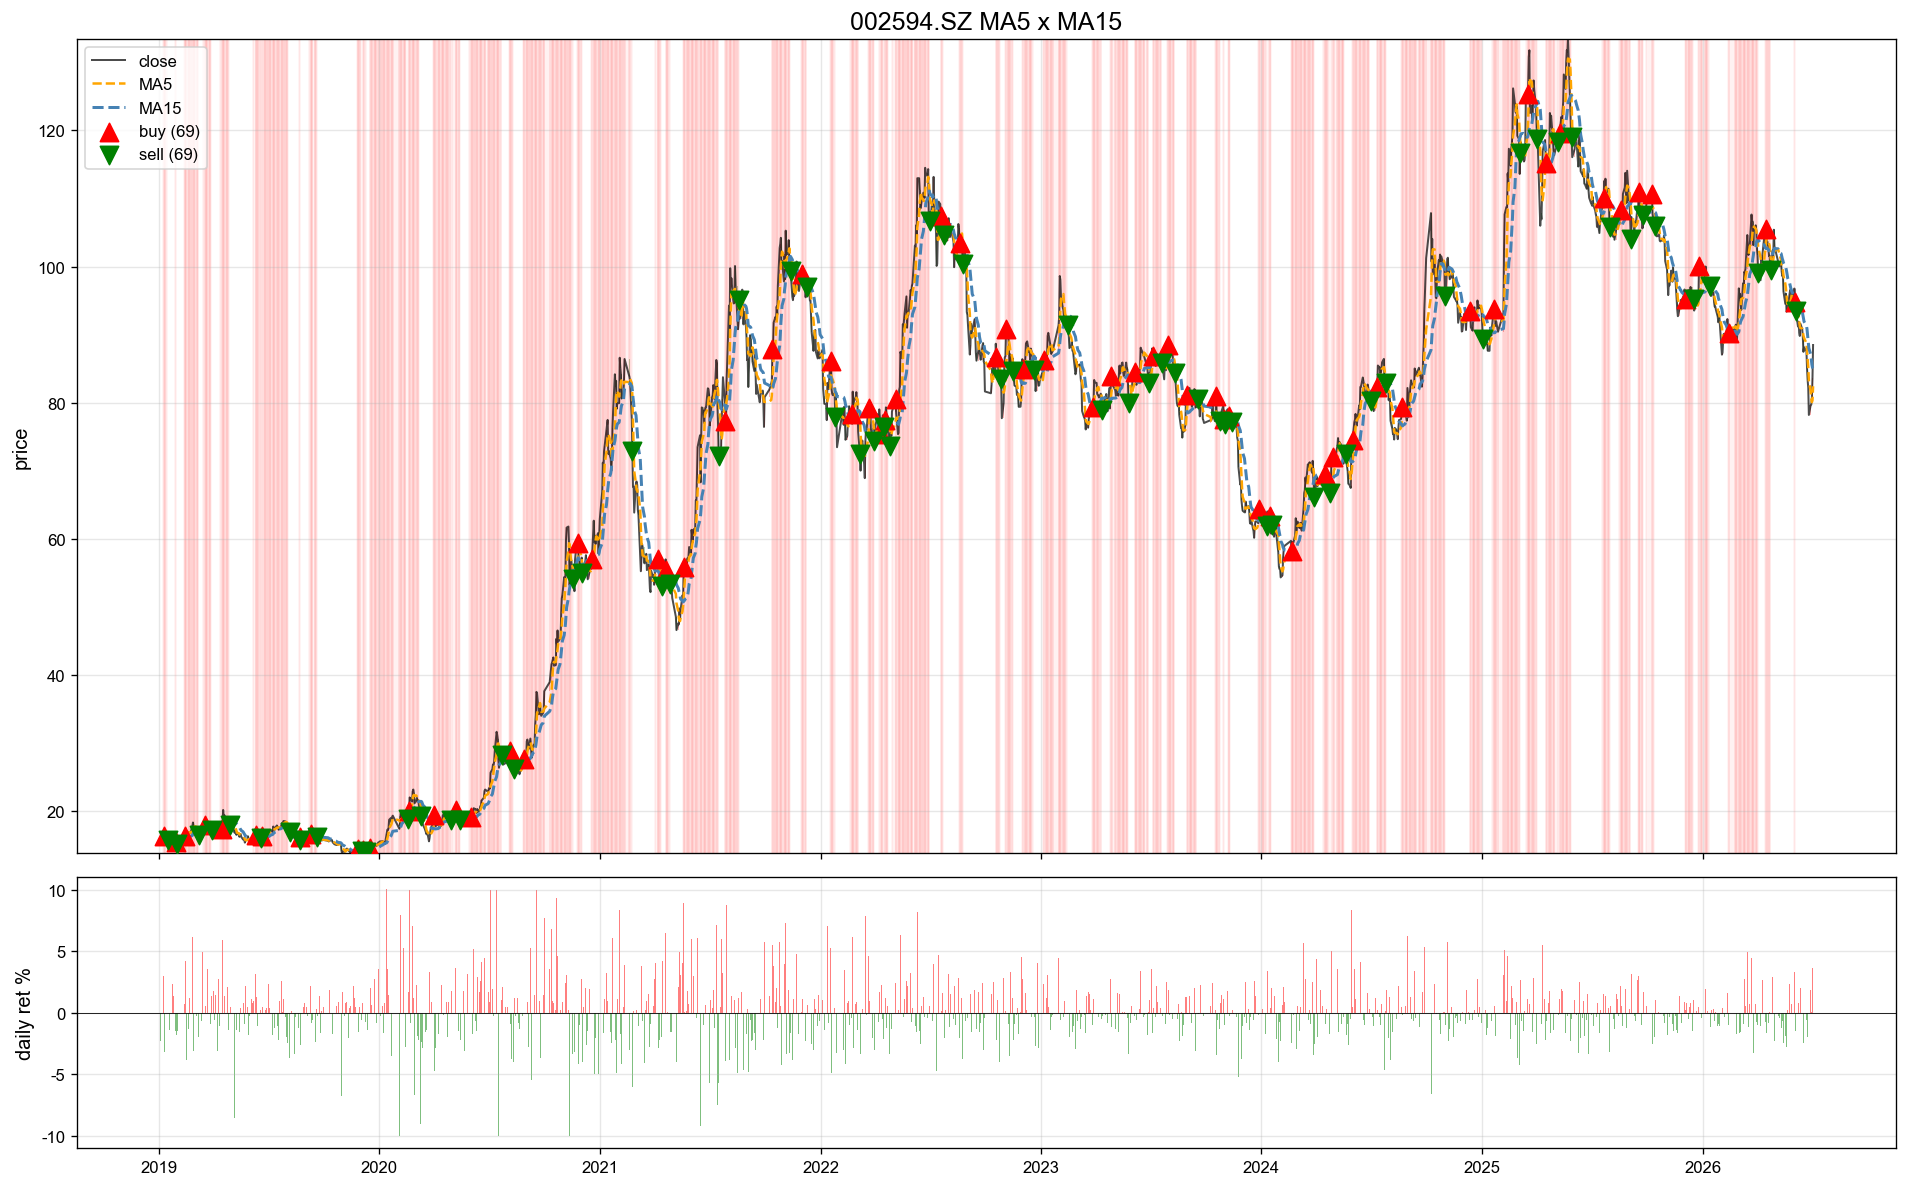

In [14]:
def plot_strategy(df, symbol, short_w, long_w, save_path=None):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax1, ax2 = axes
    # K线简化：涨红跌绿柱状图
    close_arr = df['close'].values
    chg = close_arr[1:] - close_arr[:-1]
    colors = ['red' if chg[i] >= 0 else 'green' for i in range(len(chg))]
    ax1.bar(df.index[1:], chg, bottom=close_arr[:-1], color=colors, width=0.8, alpha=0.3)
    ax1.plot(df.index, df['close'], color='black', linewidth=1.2, label='close', alpha=0.7)
    ax1.plot(df.index, df['ma_short'], color='orange', linewidth=1.5, linestyle='--', label=f'MA{short_w}')
    ax1.plot(df.index, df['ma_long'], color='steelblue', linewidth=1.8, linestyle='--', label=f'MA{long_w}')

    buy_mask = df['signal'] == 1
    sell_mask = df['signal'] == -1
    ax1.scatter(df.index[buy_mask], df['close'][buy_mask], marker='^', color='red', s=120, zorder=5, label=f'buy ({buy_mask.sum()})')
    ax1.scatter(df.index[sell_mask], df['close'][sell_mask], marker='v', color='green', s=120, zorder=5, label=f'sell ({sell_mask.sum()})')

    for i in range(1, len(df)):
        if df['position'].iloc[i] == 1:
            ax1.axvspan(df.index[i-1], df.index[i], alpha=0.05, color='red')

    ax1.set_title(f'{symbol} MA{short_w} x MA{long_w}', fontsize=15, fontweight='bold')
    ax1.set_ylabel('price', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)

    daily_ret = df['close'].pct_change() * 100
    colors_ret = ['red' if r > 0 else 'green' for r in daily_ret]
    ax2.bar(df.index, daily_ret, color=colors_ret, width=0.8, alpha=0.5)
    ax2.axhline(y=0, color='black', linewidth=0.5)
    ax2.set_ylabel('daily ret %', fontsize=12)
    ax2.grid(True, alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f'saved: {save_path}')
    plt.show()

plot_strategy(df, '002594.SZ', SHORT_WINDOW, LONG_WINDOW, save_path='dual_ma_002594.png')

## 6. 模拟交易与回测

假设：
- 初始资金 100,000
- 以收盘价成交，不考虑手续费和滑点
- 单边做多，金叉全仓买入，死叉全仓卖出

In [15]:
def backtest(df, initial_capital=100000.0):
    df = df.copy()
    df['daily_ret'] = df['close'].pct_change()
    df['strategy_ret'] = df['position'].shift(1) * df['daily_ret']
    df['strategy_ret'] = df['strategy_ret'].fillna(0)
    df['strategy_nav'] = (1 + df['strategy_ret']).cumprod() * initial_capital
    df['benchmark_nav'] = (1 + df['daily_ret']).cumprod() * initial_capital

    cumulative_return = (df['strategy_nav'].iloc[-1] / initial_capital - 1) * 100
    benchmark_return = (df['benchmark_nav'].iloc[-1] / initial_capital - 1) * 100
    n_days = len(df)
    annual_return = ((1 + cumulative_return/100) ** (252/n_days) - 1) * 100

    peak = df['strategy_nav'].expanding().max()
    drawdown = (df['strategy_nav'] - peak) / peak * 100
    max_drawdown = drawdown.min()

    valid_rets = df['strategy_ret'].dropna()
    sharpe = (valid_rets.mean() / valid_rets.std()) * np.sqrt(252) if len(valid_rets) > 0 and valid_rets.std() > 0 else 0

    trades = []
    entry_price = 0
    for i in range(len(df)):
        if df['signal'].iloc[i] == 1 and entry_price == 0:
            entry_price = df['close'].iloc[i]
        elif df['signal'].iloc[i] == -1 and entry_price > 0:
            ret = (df['close'].iloc[i] - entry_price) / entry_price
            trades.append({'entry': df.index[i], 'entry_px': entry_price, 'exit_px': df['close'].iloc[i], 'ret': ret})
            entry_price = 0
    if entry_price > 0:
        ret = (df['close'].iloc[-1] - entry_price) / entry_price
        trades.append({'entry': df.index[-1], 'entry_px': entry_price, 'exit_px': df['close'].iloc[-1], 'ret': ret})

    total_trades = len(trades)
    win_trades = sum(1 for t in trades if t['ret'] > 0)
    win_rate = (win_trades / total_trades * 100) if total_trades > 0 else 0

    return {
        '累计回报 (%)': round(cumulative_return, 2),
        '年化收益率 (%)': round(annual_return, 2),
        '最大回撤 (%)': round(max_drawdown, 2),
        '夏普比率': round(sharpe, 2),
        '胜率 (%)': round(win_rate, 1),
        '总交易次数': total_trades,
        '盈利次数': win_trades,
        '买入持有回报 (%)': round(benchmark_return, 2),
        '超额收益 (%)': round(cumulative_return - benchmark_return, 2),
        '期末净值': round(df['strategy_nav'].iloc[-1], 2),
        '策略净值': df['strategy_nav'],
        '基准净值': df['benchmark_nav'],
        '回撤序列': drawdown,
        '交易记录': trades,
    }

results = backtest(df)
print('='*50)
print('        双均线策略回测报告')
print('='*50)
for k, v in results.items():
    if k not in ('策略净值', '基准净值', '回撤序列', '交易记录'):
        print(f'  {k}: {v}')

        双均线策略回测报告
  累计回报 (%): 361.88
  年化收益率 (%): 23.63
  最大回撤 (%): -38.08
  夏普比率: 0.81
  胜率 (%): 30.4
  总交易次数: 69
  盈利次数: 21
  买入持有回报 (%): 456.07
  超额收益 (%): -94.19
  期末净值: 461878.18


### 6.1 净值曲线对比

saved: dual_ma_backtest_002594.png


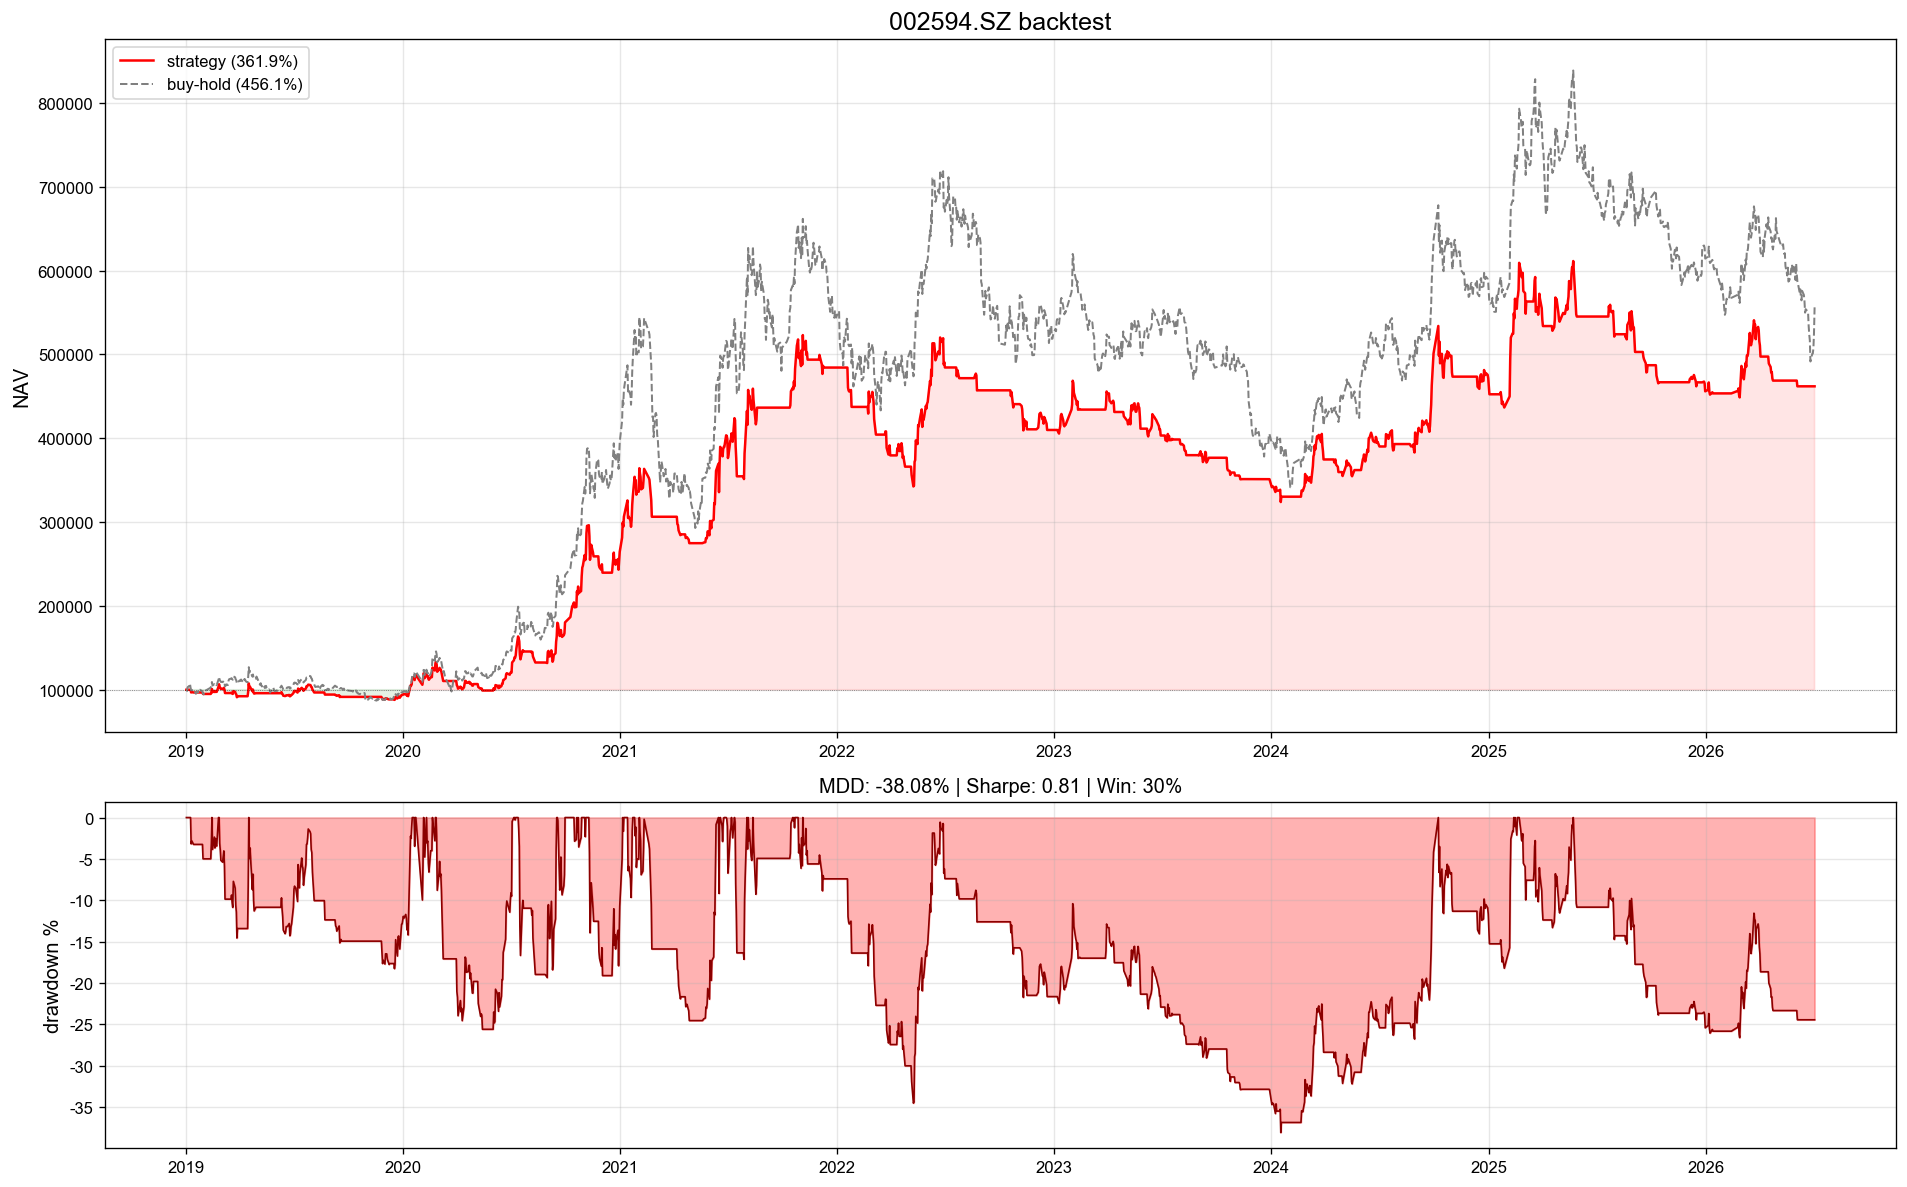

In [16]:
def plot_backtest_results(results, symbol, save_path=None):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})
    ax1, ax2 = axes
    ax1.plot(results['策略净值'].index, results['策略净值'], color='red', linewidth=1.5, label=f'strategy ({results["累计回报 (%)"]:.1f}%)')
    ax1.plot(results['基准净值'].index, results['基准净值'], color='gray', linewidth=1.2, linestyle='--', label=f'buy-hold ({results["买入持有回报 (%)"]:.1f}%)')
    ax1.axhline(y=100000, color='black', linewidth=0.5, linestyle=':', alpha=0.5)
    ax1.fill_between(results['策略净值'].index, results['策略净值'], 100000, where=results['策略净值'] >= 100000, alpha=0.1, color='red')
    ax1.fill_between(results['策略净值'].index, results['策略净值'], 100000, where=results['策略净值'] < 100000, alpha=0.1, color='green')
    ax1.set_title(f'{symbol} backtest', fontsize=15, fontweight='bold')
    ax1.set_ylabel('NAV', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax2.fill_between(results['回撤序列'].index, results['回撤序列'], 0, color='red', alpha=0.3)
    ax2.plot(results['回撤序列'].index, results['回撤序列'], color='darkred', linewidth=1)
    ax2.set_ylabel('drawdown %', fontsize=12)
    ax2.set_title(f'MDD: {results["最大回撤 (%)"]:.2f}% | Sharpe: {results["夏普比率"]:.2f} | Win: {results["胜率 (%)"]:.0f}%', fontsize=12)
    ax2.grid(True, alpha=0.3)
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f'saved: {save_path}')
    plt.show()

plot_backtest_results(results, '002594.SZ', save_path='dual_ma_backtest_002594.png')

### 6.2 逐笔交易明细

In [17]:
trades_df = pd.DataFrame(results['交易记录'])
if len(trades_df) > 0:
    trades_df['ret_pct'] = (trades_df['ret'] * 100).round(2)
    print(f'total {len(trades_df)} trades:')
    display(trades_df[['entry', 'entry_px', 'exit_px', 'ret_pct']])
else:
    print('no trades')

total 69 trades:


,entry,entry_px,exit_px,ret_pct
0,2019-01-15,16.32,15.79,-3.25
1,2019-01-30,15.53,15.25,-1.80
2,2019-03-08,16.36,16.54,1.10
3,2019-03-29,18.01,17.30,-3.94
4,2019-04-29,17.32,18.00,3.93
...,...,...,...,...
64,2025-12-17,95.24,95.21,-0.03
65,2026-01-13,100.01,97.19,-2.82
66,2026-04-03,90.27,99.01,9.68
67,2026-04-24,105.54,99.46,-5.76


## 7. 多股票多周期对比实验

对不同股票、不同均线周期组合进行回测，生成对比矩阵。

In [18]:
def run_full_experiment():
    stocks = [
        ('002594.SZ', 'BYD-A'), ('688981.SH', 'SMIC-A'),
        ('600900.SH', 'CJDL'),  ('688099.SH', 'Amlogic'),
        ('00981.HK', 'SMIC-H'), ('01211.HK', 'BYD-H'),
    ]
    combos = [(5,15),(5,20),(5,30),(10,30),(10,60),(20,60)]
    rows = []
    for symbol, name in stocks:
        df_orig = load_stock_data(symbol)
        for short, long in combos:
            df = df_orig.copy()
            df = calc_ma(df, short, long)
            df = generate_signals(df)
            r = backtest(df)
            rows.append({
                'stock': name, 'symbol': symbol,
                'ma_short': short, 'ma_long': long,
                'cum_ret': r['累计回报 (%)'],
                'annual': r['年化收益率 (%)'],
                'mdd': r['最大回撤 (%)'],
                'sharpe': r['夏普比率'],
                'win_rate': r['胜率 (%)'],
                'trades': r['总交易次数'],
                'buyhold': r['买入持有回报 (%)'],
                'excess': r['超额收益 (%)'],
            })
    return pd.DataFrame(rows)

matrix = run_full_experiment()
matrix.to_csv('backtest_matrix.csv', index=False, encoding='utf-8-sig')
print('saved: backtest_matrix.csv')
matrix.head(12)

002594.SZ: 1818 行, 2019-01-02 ~ 2026-07-03
  前复权收盘价: 15.91 ~ 88.47
MA5: 82.41
MA15: 85.07
买入信号: 69 次, 卖出信号: 69 次
最新持仓状态: 空仓
MA5: 82.41
MA20: 86.61
买入信号: 64 次, 卖出信号: 64 次
最新持仓状态: 空仓
MA5: 82.41
MA30: 89.48
买入信号: 49 次, 卖出信号: 49 次
最新持仓状态: 空仓
MA10: 82.83
MA30: 89.48
买入信号: 36 次, 卖出信号: 36 次
最新持仓状态: 空仓
MA10: 82.83
MA60: 94.91
买入信号: 24 次, 卖出信号: 24 次
最新持仓状态: 空仓
MA20: 86.61
MA60: 94.91
买入信号: 17 次, 卖出信号: 17 次
最新持仓状态: 空仓
688981.SH: 1440 行, 2020-07-16 ~ 2026-07-03
  前复权收盘价: 82.92 ~ 140.31
MA5: 149.74
MA15: 143.61
买入信号: 54 次, 卖出信号: 53 次
最新持仓状态: 持仓
MA5: 149.74
MA20: 139.17
买入信号: 42 次, 卖出信号: 41 次
最新持仓状态: 持仓
MA5: 149.74
MA30: 139.79
买入信号: 37 次, 卖出信号: 36 次
最新持仓状态: 持仓
MA10: 149.31
MA30: 139.79
买入信号: 31 次, 卖出信号: 30 次
最新持仓状态: 持仓
MA10: 149.31
MA60: 126.30
买入信号: 17 次, 卖出信号: 16 次
最新持仓状态: 持仓
MA20: 139.17
MA60: 126.30
买入信号: 16 次, 卖出信号: 15 次
最新持仓状态: 持仓
600900.SH: 1807 行, 2019-01-02 ~ 2026-07-03
  前复权收盘价: 12.52 ~ 27.05
MA5: 26.79
MA15: 26.93
买入信号: 79 次, 卖出信号: 79 次
最新持仓状态: 空仓
MA5: 26.79
MA20: 27.11
买入信号: 64 次, 卖出信号

,stock,symbol,ma_short,ma_long,cum_ret,annual,mdd,sharpe,win_rate,trades,buyhold,excess
0,BYD-A,002594.SZ,5,15,361.88,23.63,-38.08,0.81,30.4,69,456.07,-94.19
1,BYD-A,002594.SZ,5,20,280.51,20.35,-41.63,0.73,29.7,64,456.07,-175.55
2,BYD-A,002594.SZ,5,30,331.23,22.46,-38.93,0.77,34.7,49,456.07,-124.84
3,BYD-A,002594.SZ,10,30,208.65,16.91,-37.20,0.64,52.8,36,456.07,-247.42
4,BYD-A,002594.SZ,10,60,410.10,25.34,-29.14,0.83,41.7,24,456.07,-45.96
5,BYD-A,002594.SZ,20,60,375.36,24.12,-36.20,0.80,47.1,17,456.07,-80.71
6,SMIC-A,688981.SH,5,15,42.62,6.41,-49.05,0.35,29.6,54,69.21,-26.59
7,SMIC-A,688981.SH,5,20,82.57,11.11,-36.19,0.47,38.1,42,69.21,13.36
8,SMIC-A,688981.SH,5,30,7.01,1.19,-51.10,0.20,29.7,37,69.21,-62.21
9,SMIC-A,688981.SH,10,30,-20.21,-3.87,-55.16,0.04,32.3,31,69.21,-89.42


### 7.1 按股票分组查看最佳参数

In [19]:
best = matrix.loc[matrix.groupby('stock')['cum_ret'].idxmax()]
best = best[['stock', 'ma_short', 'ma_long', 'cum_ret', 'annual', 'mdd', 'sharpe', 'win_rate', 'excess']]
display(best.sort_values('cum_ret', ascending=False))

,stock,ma_short,ma_long,cum_ret,annual,mdd,sharpe,win_rate,excess
25,SMIC-H,5,20,876.85,34.91,-57.38,0.90,38.6,85.92
4,BYD-A,10,60,410.10,25.34,-29.14,0.83,41.7,-45.96
30,BYD-H,5,15,296.41,19.84,-46.62,0.66,39.5,225.13
7,SMIC-A,5,20,82.57,11.11,-36.19,0.47,38.1,13.36
15,CJDL,10,30,52.21,6.03,-16.79,0.50,50.0,-63.84
23,Amlogic,20,60,-19.92,-3.29,-57.50,0.11,29.4,12.10


### 7.2 按均线组合查看平均表现

In [20]:
avg = matrix.groupby(['ma_short', 'ma_long']).agg({'cum_ret':'mean','sharpe':'mean','win_rate':'mean','excess':'mean'}).round(2)
display(avg.sort_values('cum_ret', ascending=False))

cum_ret  sharpe  win_rate  excess
ma_short ma_long                                   
5        20        232.42    0.48     35.77  -12.83
         15        184.84    0.47     35.02  -60.41
         30        146.53    0.42     33.47  -98.73
10       30        141.85    0.40     42.05 -103.40
         60        113.40    0.38     37.98 -131.85
20       60         74.94    0.35     43.05 -170.32

## 8. 策略总结与心得

### 双均线策略的适用场景

1. **强趋势市**：策略在单边上涨/下跌行情中表现优秀，能有效捕捉趋势
2. **高波动性股票**：波动越大的股票，金叉/死叉信号的价值越高

### 策略局限性

1. **震荡市假信号**：横盘震荡时频繁产生金叉死叉，导致反复止损
2. **滞后性**：均线是滞后指标，买卖点通常晚于价格转折点
3. **参数敏感性**：不同股票和时期的最优参数差异较大

### 改进方向

1. 引入 ADX 趋势强度过滤，仅在趋势明显时交易
2. 结合成交量确认信号有效性
3. 加入止损机制控制单笔最大亏损
4. 与其他指标（MACD、RSI）组合使用
5. 利用机器学习优化参数选择

### 参数选择建议

- **短周期 MA(5,15)**：敏感度高，适合短线交易，但假信号多
- **中周期 MA(10,30)**：平衡性较好，适合中等周期趋势
- **长周期 MA(20,60)**：信号少但可靠性高，适合捕捉大趋势